In [1]:
pip install tensorflow  


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# =========================
# XGBOOST - G94 DATASET
# =========================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier


In [3]:
df = pd.read_csv(r"C:\Users\Admin\Downloads/G94.csv")
df.head()

,TopDepth,BotDepth,_CAL,_GR,_SP,_LLD,_LLS,_AC,_DEN,_PEF,Lith_Section
0,1641.65,1642.78,9.19011,78.6822,-19.2815,12.0988,7.60498,98.7288,2.27724,0.928296,mudstone
1,1642.78,1643.42,9.19011,69.0777,-18.9724,13.0187,13.52050,91.4849,2.24234,0.912831,oil shale
2,1643.42,1644.18,9.16741,73.2881,-19.2862,12.9812,12.78340,97.9065,2.20452,0.896096,silty mudstone
3,1644.18,1646.58,9.16741,82.4644,-18.6205,15.5065,26.61860,95.3392,2.14926,0.889257,oil shale
4,1646.58,1647.66,9.20042,106.0230,-17.9354,14.0295,18.94550,113.0850,2.07945,0.883297,silty mudstone


In [4]:

# Step 3: Separate Features & Target
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column (Lithology)

In [5]:
# Step 4: Handle Missing Values
X = X.fillna(X.mean())

In [6]:

# Step 5: Encode Target (text → numbers)
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [7]:
# Step 6: Train XGBoost Model
model = XGBClassifier(
    n_estimators=300,       # number of trees
    max_depth=7,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X, y_enc)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [12:19:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
# Step 7: Prediction
y_pred = model.predict(X)


In [9]:
# Step 8: Accuracy
acc = accuracy_score(y_enc, y_pred)
print("G94 XGBoost Accuracy:", acc)


G94 XGBoost Accuracy: 1.0


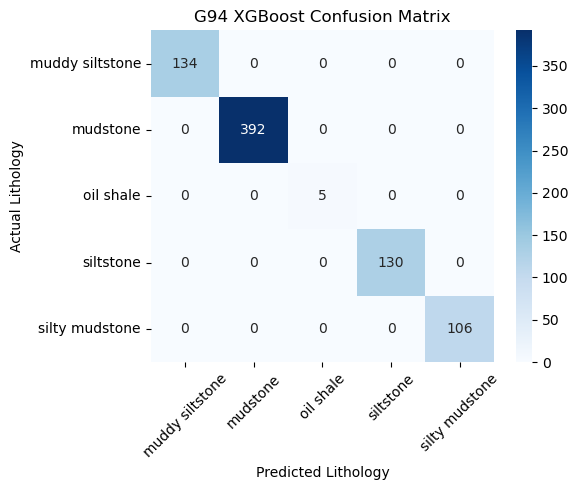

In [10]:
# Step 9: Confusion Matrix
cm = confusion_matrix(y_enc, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',          # shows normal numbers
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("G94 XGBoost Confusion Matrix")
plt.xlabel("Predicted Lithology")
plt.ylabel("Actual Lithology")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()